# US county-level sociodemographic and health resource data (2018-2019)

## Objective

Build a linear regression notebook in Python to study the relationship between sociodemographic variables and a health-related target variable at the US county level.

In this version, the code is intentionally kept simpler:
- clear variable names
- fewer advanced transformations
- only **numeric columns** are used for the models
- step-by-step structure


## Step 1: Load the dataset

The dataset is loaded directly from the provided URL.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [29]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=418&path=demographic_health_data.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (3140, 108)


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


## Step 2: Perform a full EDA

We first inspect:
- the structure of the dataset
- missing values
- summary statistics
- correlations with the target


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [31]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False).head(20)

Series([], dtype: int64)

In [32]:
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.000000,18180.500000,29178.000000,45081.500000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.000000,10963.250000,25800.500000,67913.000000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.000000,1280.500000,3057.000000,8097.000000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.000000,10.594639,11.802727,12.951840,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.000000,1374.500000,3274.000000,8822.250000,1.239139e+06
10-19 y/o % of total pop,3140.0,12.694609,1.815044,0.000000,11.674504,12.687422,13.659282,2.330437e+01
20-29,3140.0,14469.331529,49577.725396,0.000000,1263.750000,3108.000000,8976.250000,1.557073e+06
20-29 y/o % of total pop,3140.0,12.283979,3.126297,0.000000,10.496774,11.772649,13.182260,3.757020e+01
30-39,3140.0,13916.490127,48990.951710,11.000000,1232.750000,3000.500000,8314.250000,1.501844e+06
30-39 y/o % of total pop,3140.0,11.751535,1.696599,6.092789,10.689322,11.580861,12.639379,2.222513e+01


### Choose the target variable

For this notebook, the target variable will be:

**`Total Specialist Physicians (2019)`**

This is a health-related resource variable, so it fits the project goal.


In [33]:
target = "Total Specialist Physicians (2019)"
print("Target:", target)

Target: Total Specialist Physicians (2019)


In [34]:
df_model = df.copy()

if "fips" in df_model.columns:
    df_model = df_model.drop(columns=["fips"])

numeric_columns = df_model.select_dtypes(include=["int64", "float64"]).columns
df_model = df_model[numeric_columns]

print("New shape after keeping only numeric columns:", df_model.shape)
df_model.head()

New shape after keeping only numeric columns: (3140, 105)


,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [35]:
correlation_with_target = df_model.corr()[target].drop(target).sort_values(key=abs, ascending=False)
correlation_with_target.head(20)

Internal Medicine Primary Care (2019)    0.994717
Total nurse practitioners (2019)         0.976474
60-69                                    0.967737
Population Aged 60+                      0.967231
50-59                                    0.967222
Total Population                         0.966606
county_pop2018_18 and older              0.966521
Civilian_labor_force_2018                0.964078
Employed_2018                            0.963819
Total physician assistants (2019)        0.963811
TOT_POP                                  0.963610
POP_ESTIMATE_2018                        0.963610
CKD_number                               0.959149
30-39                                    0.958650
20-29                                    0.958605
80+                                      0.958441
High school diploma only 2014-18         0.957956
Bachelor's degree or higher 2014-18      0.957133
40-49                                    0.957102
70-79                                    0.955367


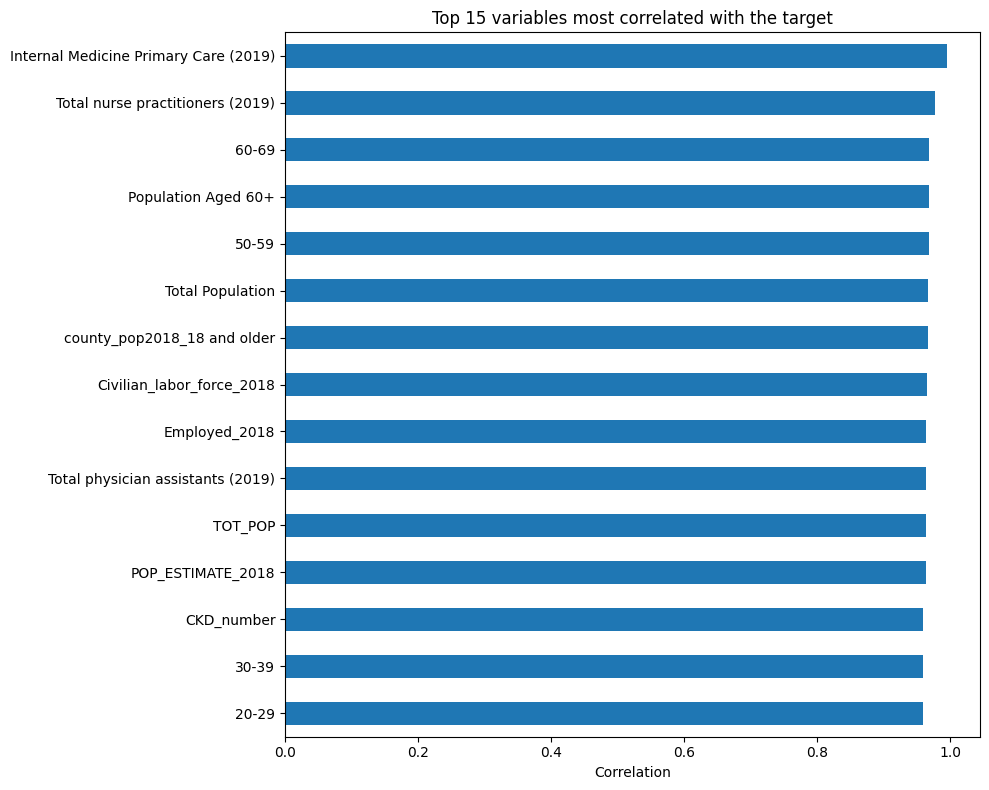

In [36]:
plt.figure(figsize=(10, 8))
correlation_with_target.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 variables most correlated with the target")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

### Train-test split

Now we divide the dataset into:
- `X`: input features
- `y`: target variable
- training set
- test set


In [37]:
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2512, 104)
X_test: (628, 104)
y_train: (2512,)
y_test: (628,)


## Step 3: Build a baseline Linear Regression model

We use a simple pipeline:
1. fill missing numeric values with the median
2. scale the data
3. train a linear regression model


In [38]:
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression")
print("R2:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

Linear Regression
R2: 0.994039905539434
MAE: 10.7920735834928
RMSE: 25.14657801327832


## Lasso model with default parameters

Now we train a Lasso model with default settings and compare it with Linear Regression.


In [39]:
lasso_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso())
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso default")
print("R2:", lasso_r2)
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)

Lasso default
R2: 0.9965865058216309
MAE: 8.36575111706755
RMSE: 19.030574792152333


In [40]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso default"],
    "R2": [lr_r2, lasso_r2],
    "MAE": [lr_mae, lasso_mae],
    "RMSE": [lr_rmse, lasso_rmse]
})

comparison

,Model,R2,MAE,RMSE
0,Linear Regression,0.994040,10.792074,25.146578
1,Lasso default,0.996587,8.365751,19.030575


## Analyze how `R²` changes when `alpha` changes

Try different values of `alpha` for Lasso.
- `alpha = 0` will be represented by the Linear Regression baseline
- then we test Lasso with values from `0.1` to `20`


In [41]:
alpha_values = [0.0] + list(np.linspace(0.1, 20, 40))
r2_scores = []

for alpha in alpha_values:
    if alpha == 0.0:
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ])
    else:
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=alpha, max_iter=20000))
        ])

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    score = r2_score(y_test, predictions)
    r2_scores.append(score)

r2_alpha_df = pd.DataFrame({
    "alpha": alpha_values,
    "r2": r2_scores
})

r2_alpha_df.head()

,alpha,r2
0,0.000000,0.994040
1,0.100000,0.996084
2,0.610256,0.996593
3,1.120513,0.996591
4,1.630769,0.996679


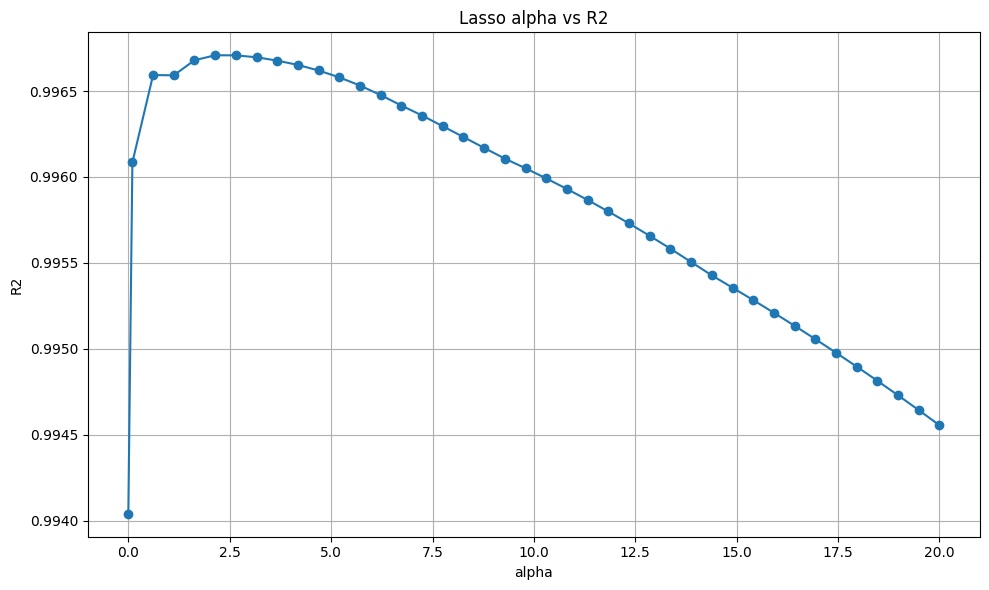

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(r2_alpha_df["alpha"], r2_alpha_df["r2"], marker="o")
plt.title("Lasso alpha vs R2")
plt.xlabel("alpha")
plt.ylabel("R2")
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 4: Optimize the Lasso model

A simple way to optimize Lasso is to search for a better `alpha` with `GridSearchCV`.


In [45]:
lasso_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=100))
])

param_grid = {
    "model__alpha": np.logspace(-3, 1.5, 25)
}

grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.717e+06, tolerance: 7.360e+04
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.520e+06, tolerance: 7.617e+04
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1

Best alpha: {'model__alpha': np.float64(2.371373705661655)}
Best CV score: 0.995740545486575


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.023e+06, tolerance: 6.685e+04
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.339e+06, tolerance: 7.684e+04
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1

In [46]:
best_lasso = grid_search.best_estimator_

y_pred_best = best_lasso.predict(X_test)

best_r2 = r2_score(y_test, y_pred_best)
best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Optimized Lasso")
print("R2:", best_r2)
print("MAE:", best_mae)
print("RMSE:", best_rmse)

Optimized Lasso
R2: 0.9969264782604209
MAE: 7.933402558327167
RMSE: 18.0580340317561


In [47]:
final_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso default", "Lasso optimized"],
    "R2": [lr_r2, lasso_r2, best_r2],
    "MAE": [lr_mae, lasso_mae, best_mae],
    "RMSE": [lr_rmse, lasso_rmse, best_rmse]
})

final_comparison.sort_values(by="R2", ascending=False)

,Model,R2,MAE,RMSE
2,Lasso optimized,0.996926,7.933403,18.058034
1,Lasso default,0.996587,8.365751,19.030575
0,Linear Regression,0.994040,10.792074,25.146578
